# RLAD Noise-Control Experiment: Track A (Clean) vs Track B (Mixed) Analysis

This notebook analyzes the results of the RLAD noise-control experiment, comparing:
- **Track A (clean):** Trained on standard GSM8K data (244 steps before SIGTERM)
- **Track B (mixed):** Trained on GSM8K with prepended trivia facts (400 steps completed)

Both tracks use identical hyperparameters and evaluate on the same clean test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load data
df_a = pd.read_csv('track_a_history.csv')
df_b = pd.read_csv('track_b_history.csv')

with open('track_a_summary.json') as f:
    summary_a = json.load(f)
with open('track_b_summary.json') as f:
    summary_b = json.load(f)

print(f"Track A: {len(df_a)} rows, steps: {df_a['_step'].min():.0f} - {df_a['_step'].max():.0f}")
print(f"Track B: {len(df_b)} rows, steps: {df_b['_step'].min():.0f} - {df_b['_step'].max():.0f}")

Track A: 241 rows, steps: 3 - 243
Track B: 401 rows, steps: 0 - 400


## 1. Learning Curve Comparison (Validation Accuracy)

We compare validation reward (accuracy) over steps for both tracks, aligned to the same step range (0-244).

In [2]:
# Filter to common step range
max_step = min(df_a['_step'].max(), df_b['_step'].max())
df_a_aligned = df_a[df_a['_step'] <= max_step].copy()
df_b_aligned = df_b[df_b['_step'] <= max_step].copy()

# Find validation reward columns
val_cols_a = [c for c in df_a.columns if 'val/openai/gsm8k/reward/mean' in c]
val_cols_b = [c for c in df_b.columns if 'val/openai/gsm8k/reward/mean' in c]

print("Validation columns found:")
print(f"  Track A: {val_cols_a}")
print(f"  Track B: {val_cols_b}")

Validation columns found:
  Track A: ['val/openai/gsm8k/reward/mean']
  Track B: ['val/openai/gsm8k/reward/mean']


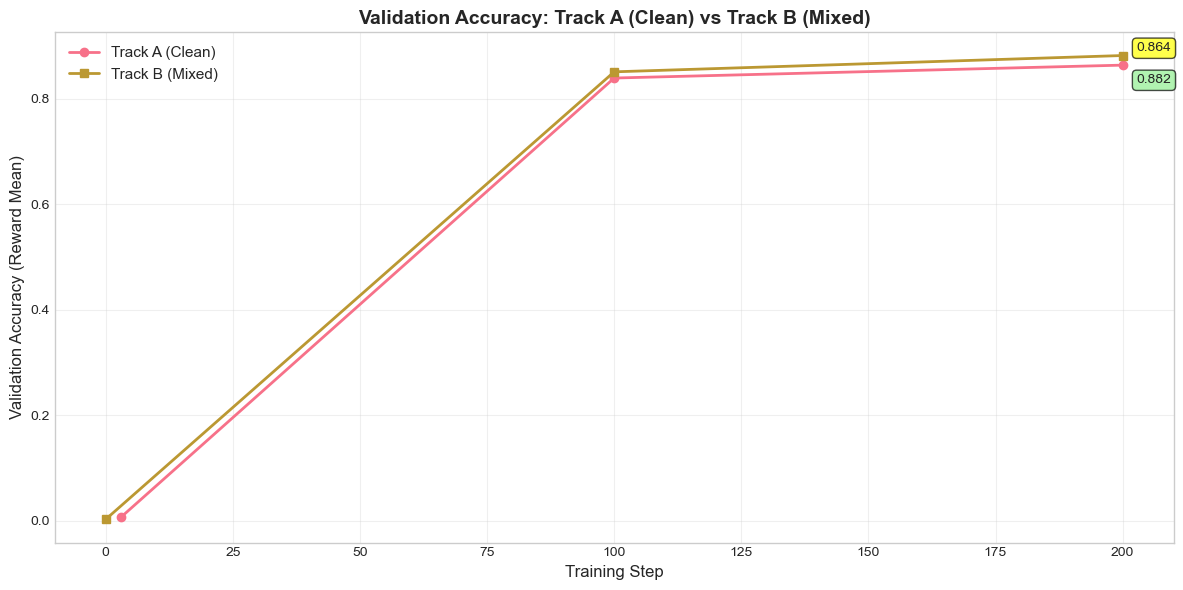


Validation Accuracy at Common Steps:
Step     Track A      Track B      Delta (B-A)    
--------------------------------------------------
100      0.8391       0.8508       +0.0118        
200      0.8635       0.8817       +0.0182        


In [3]:
# Plot validation accuracy over steps
fig, ax = plt.subplots(figsize=(12, 6))

# Get validation data (non-null values only)
val_a = df_a_aligned[df_a_aligned['val/openai/gsm8k/reward/mean'].notna()]
val_b = df_b_aligned[df_b_aligned['val/openai/gsm8k/reward/mean'].notna()]

ax.plot(val_a['_step'], val_a['val/openai/gsm8k/reward/mean'], 'o-', label='Track A (Clean)', linewidth=2, markersize=6)
ax.plot(val_b['_step'], val_b['val/openai/gsm8k/reward/mean'], 's-', label='Track B (Mixed)', linewidth=2, markersize=6)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Validation Accuracy (Reward Mean)', fontsize=12)
ax.set_title('Validation Accuracy: Track A (Clean) vs Track B (Mixed)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotations for final values
if len(val_a) > 0:
    ax.annotate(f"{val_a['val/openai/gsm8k/reward/mean'].iloc[-1]:.3f}", 
                xy=(val_a['_step'].iloc[-1], val_a['val/openai/gsm8k/reward/mean'].iloc[-1]),
                xytext=(10, 10), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

if len(val_b) > 0:
    ax.annotate(f"{val_b['val/openai/gsm8k/reward/mean'].iloc[-1]:.3f}", 
                xy=(val_b['_step'].iloc[-1], val_b['val/openai/gsm8k/reward/mean'].iloc[-1]),
                xytext=(10, -20), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('validation_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print step-by-step comparison
print("\nValidation Accuracy at Common Steps:")
print(f"{'Step':<8} {'Track A':<12} {'Track B':<12} {'Delta (B-A)':<15}")
print("-" * 50)
for step in sorted(set(val_a['_step']) & set(val_b['_step'])):
    a_val = val_a[val_a['_step'] == step]['val/openai/gsm8k/reward/mean'].values
    b_val = val_b[val_b['_step'] == step]['val/openai/gsm8k/reward/mean'].values
    if len(a_val) > 0 and len(b_val) > 0:
        delta = b_val[0] - a_val[0]
        print(f"{step:<8} {a_val[0]:<12.4f} {b_val[0]:<12.4f} {delta:<+15.4f}")

## 2. Timing Efficiency Analysis

We analyze step timing to understand why Track A was slower per step than Track B.

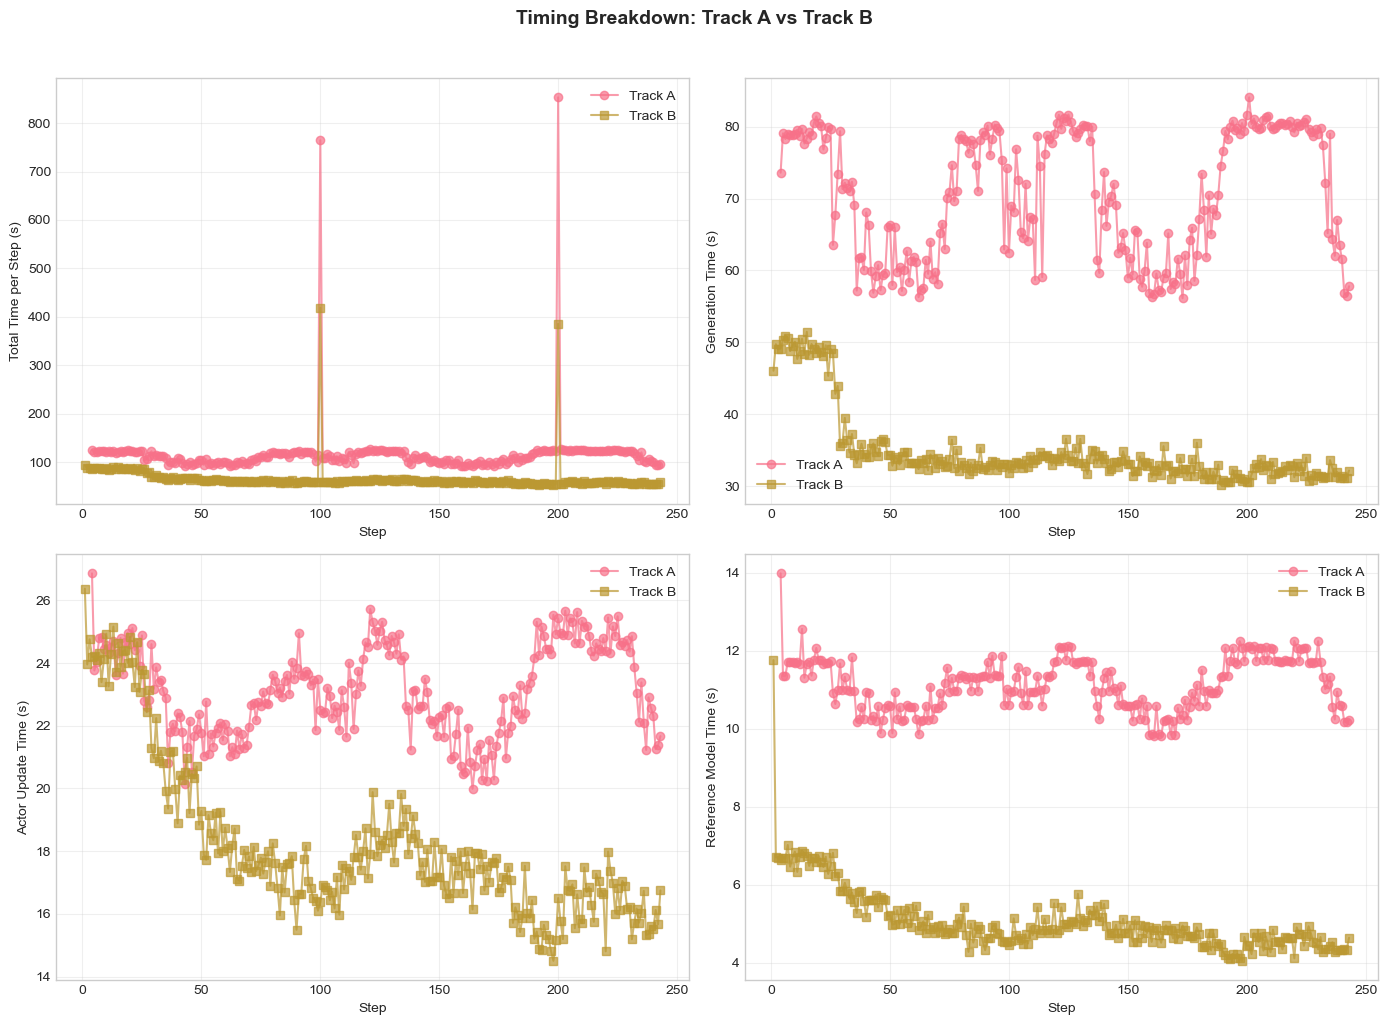


Average Timing Comparison (seconds):
Metric                         Track A      Track B      Ratio (A/B)    
----------------------------------------------------------------------
Total Time per Step (s)        117.28       65.96        1.78           
Generation Time (s)            70.82        34.84        2.03           
Actor Update Time (s)          23.14        18.21        1.27           
Reference Model Time (s)       11.14        5.07         2.20           


In [4]:
# Plot timing comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

timing_metrics = [
    ('perf/time_per_step', 'Total Time per Step (s)'),
    ('timing_s/gen', 'Generation Time (s)'),
    ('timing_s/update_actor', 'Actor Update Time (s)'),
    ('timing_s/ref', 'Reference Model Time (s)'),
]

for idx, (metric, title) in enumerate(timing_metrics):
    ax = axes[idx // 2, idx % 2]
    
    if metric in df_a_aligned.columns:
        data_a = df_a_aligned[df_a_aligned[metric].notna()]
        ax.plot(data_a['_step'], data_a[metric], 'o-', label='Track A', alpha=0.7)
    
    if metric in df_b_aligned.columns:
        data_b = df_b_aligned[df_b_aligned[metric].notna()]
        ax.plot(data_b['_step'], data_b[metric], 's-', label='Track B', alpha=0.7)
    
    ax.set_xlabel('Step')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Timing Breakdown: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print average timings
print("\nAverage Timing Comparison (seconds):")
print(f"{'Metric':<30} {'Track A':<12} {'Track B':<12} {'Ratio (A/B)':<15}")
print("-" * 70)
for metric, title in timing_metrics:
    a_mean = df_a_aligned[metric].mean() if metric in df_a_aligned.columns else np.nan
    b_mean = df_b_aligned[metric].mean() if metric in df_b_aligned.columns else np.nan
    ratio = a_mean / b_mean if b_mean > 0 else np.nan
    print(f"{title:<30} {a_mean:<12.2f} {b_mean:<12.2f} {ratio:<15.2f}")

## 3. Response Length Dynamics

Response length is a proxy for 'rambling.' We compare how quickly each track learned to write concise answers.

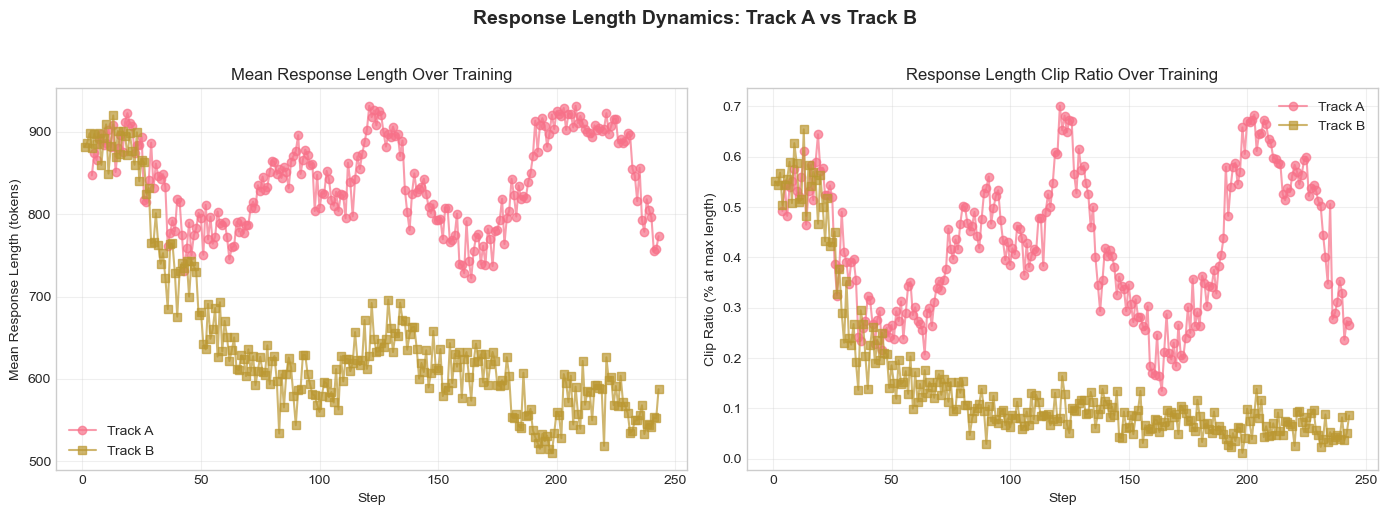


Response Length Statistics (at final common step):
Last common step: 243
  Track A mean length: 773.4 tokens
  Track B mean length: 587.5 tokens
  Track A clip ratio: 26.6%
  Track B clip ratio: 8.6%


In [5]:
# Plot response length metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean response length
ax = axes[0]
if 'response_length/mean' in df_a_aligned.columns:
    ax.plot(df_a_aligned['_step'], df_a_aligned['response_length/mean'], 'o-', label='Track A', alpha=0.7)
if 'response_length/mean' in df_b_aligned.columns:
    ax.plot(df_b_aligned['_step'], df_b_aligned['response_length/mean'], 's-', label='Track B', alpha=0.7)
ax.set_xlabel('Step')
ax.set_ylabel('Mean Response Length (tokens)')
ax.set_title('Mean Response Length Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

# Clip ratio (responses hitting max length)
ax = axes[1]
if 'response_length/clip_ratio' in df_a_aligned.columns:
    ax.plot(df_a_aligned['_step'], df_a_aligned['response_length/clip_ratio'], 'o-', label='Track A', alpha=0.7)
if 'response_length/clip_ratio' in df_b_aligned.columns:
    ax.plot(df_b_aligned['_step'], df_b_aligned['response_length/clip_ratio'], 's-', label='Track B', alpha=0.7)
ax.set_xlabel('Step')
ax.set_ylabel('Clip Ratio (% at max length)')
ax.set_title('Response Length Clip Ratio Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Response Length Dynamics: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('response_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key statistics
print("\nResponse Length Statistics (at final common step):")
common_steps = sorted(set(df_a_aligned['_step']) & set(df_b_aligned['_step']))
if common_steps:
    last_step = max(common_steps)
    a_last = df_a_aligned[df_a_aligned['_step'] == last_step]
    b_last = df_b_aligned[df_b_aligned['_step'] == last_step]
    
    print(f"Last common step: {last_step}")
    print(f"  Track A mean length: {a_last['response_length/mean'].values[0]:.1f} tokens")
    print(f"  Track B mean length: {b_last['response_length/mean'].values[0]:.1f} tokens")
    print(f"  Track A clip ratio: {a_last['response_length/clip_ratio'].values[0]:.1%}")
    print(f"  Track B clip ratio: {b_last['response_length/clip_ratio'].values[0]:.1%}")

## 4. Reward and Advantage Distribution

We examine training reward statistics to understand exploration vs. exploitation dynamics.

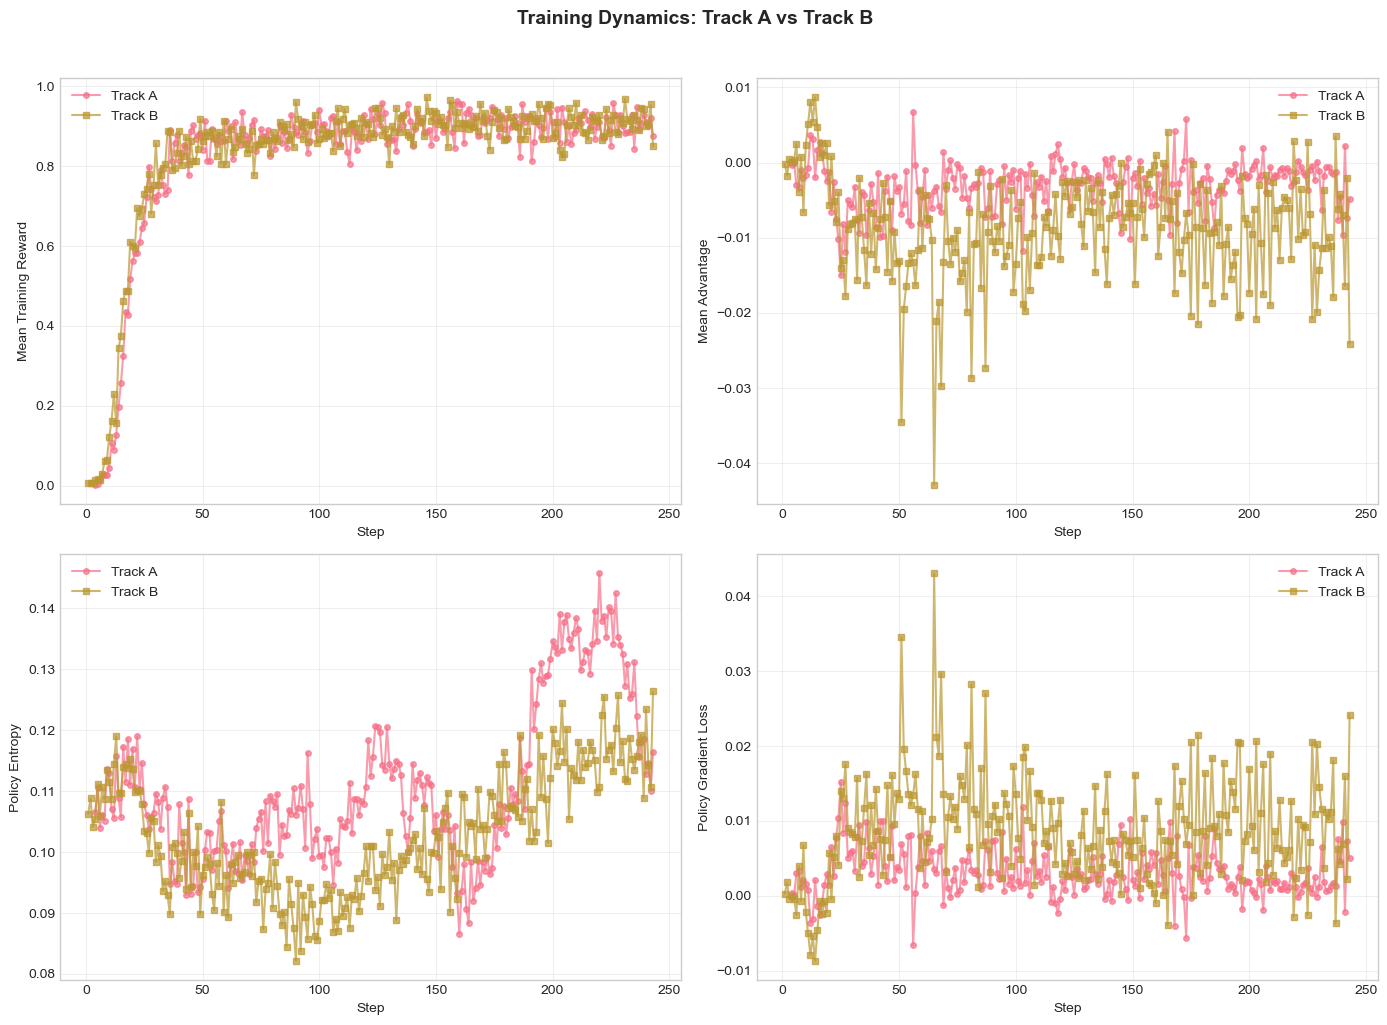

In [6]:
# Plot reward and advantage metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('critic/rewards/mean', 'Mean Training Reward'),
    ('critic/advantages/mean', 'Mean Advantage'),
    ('actor/entropy', 'Policy Entropy'),
    ('actor/pg_loss', 'Policy Gradient Loss'),
]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    if metric in df_a_aligned.columns:
        data_a = df_a_aligned[df_a_aligned[metric].notna()]
        ax.plot(data_a['_step'], data_a[metric], 'o-', label='Track A', alpha=0.7, markersize=4)
    
    if metric in df_b_aligned.columns:
        data_b = df_b_aligned[df_b_aligned[metric].notna()]
        ax.plot(data_b['_step'], data_b[metric], 's-', label='Track B', alpha=0.7, markersize=4)
    
    ax.set_xlabel('Step')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Dynamics: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Memory Utilization

We check GPU memory pressure for both tracks.

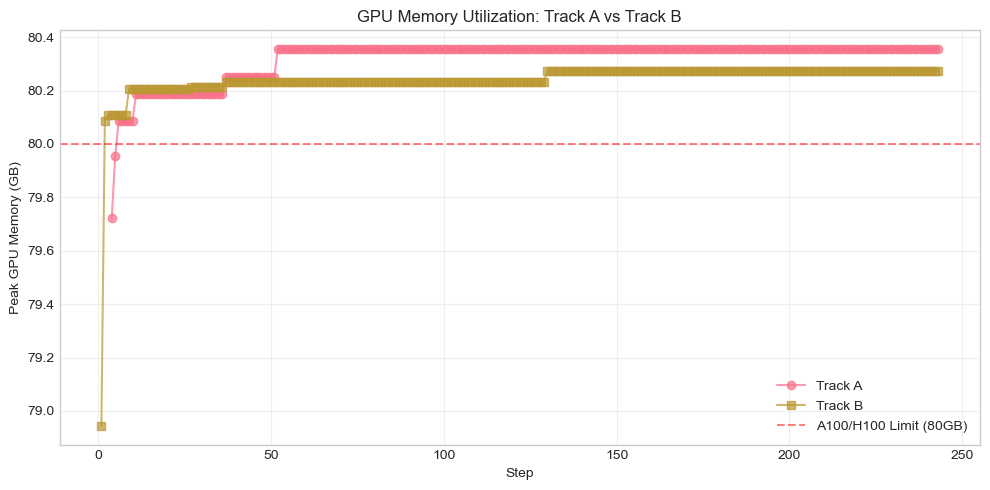


GPU Memory Statistics:
  Track A peak: 80.35 GB
  Track B peak: 80.27 GB


In [7]:
# Plot memory metrics
fig, ax = plt.subplots(figsize=(10, 5))

if 'perf/max_memory_allocated_gb' in df_a_aligned.columns:
    ax.plot(df_a_aligned['_step'], df_a_aligned['perf/max_memory_allocated_gb'], 'o-', label='Track A', alpha=0.7)
if 'perf/max_memory_allocated_gb' in df_b_aligned.columns:
    ax.plot(df_b_aligned['_step'], df_b_aligned['perf/max_memory_allocated_gb'], 's-', label='Track B', alpha=0.7)

ax.axhline(y=80, color='r', linestyle='--', alpha=0.5, label='A100/H100 Limit (80GB)')
ax.set_xlabel('Step')
ax.set_ylabel('Peak GPU Memory (GB)')
ax.set_title('GPU Memory Utilization: Track A vs Track B')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print memory stats
print("\nGPU Memory Statistics:")
if 'perf/max_memory_allocated_gb' in df_a_aligned.columns:
    print(f"  Track A peak: {df_a_aligned['perf/max_memory_allocated_gb'].max():.2f} GB")
if 'perf/max_memory_allocated_gb' in df_b_aligned.columns:
    print(f"  Track B peak: {df_b_aligned['perf/max_memory_allocated_gb'].max():.2f} GB")

## 6. Step-wise Accuracy Gap

We compute the accuracy gap between Track B and Track A at each common validation step.

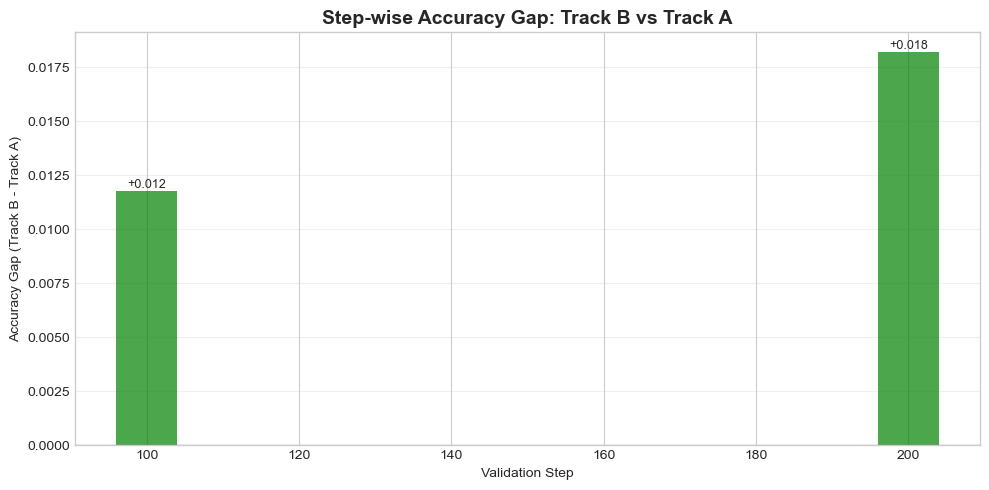


Accuracy Gap Summary:
 step  track_a  track_b      gap
  100 0.839083 0.850834 0.011751
  200 0.863533 0.881729 0.018196

Average gap: +0.0150
Max gap: +0.0182 at step 200
Min gap: +0.0118 at step 100


In [8]:
# Compute accuracy gap at common validation steps
val_a = df_a_aligned[df_a_aligned['val/openai/gsm8k/reward/mean'].notna()]
val_b = df_b_aligned[df_b_aligned['val/openai/gsm8k/reward/mean'].notna()]

common_val_steps = sorted(set(val_a['_step']) & set(val_b['_step']))

gaps = []
for step in common_val_steps:
    a_val = val_a[val_a['_step'] == step]['val/openai/gsm8k/reward/mean'].values[0]
    b_val = val_b[val_b['_step'] == step]['val/openai/gsm8k/reward/mean'].values[0]
    gaps.append({'step': step, 'track_a': a_val, 'track_b': b_val, 'gap': b_val - a_val})

gap_df = pd.DataFrame(gaps)

# Plot gap
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['green' if g > 0 else 'red' for g in gap_df['gap']]
ax.bar(gap_df['step'], gap_df['gap'], color=colors, alpha=0.7, width=8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Validation Step')
ax.set_ylabel('Accuracy Gap (Track B - Track A)')
ax.set_title('Step-wise Accuracy Gap: Track B vs Track A', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for _, row in gap_df.iterrows():
    ax.text(row['step'], row['gap'], f"{row['gap']:+.3f}", 
            ha='center', va='bottom' if row['gap'] > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAccuracy Gap Summary:")
print(gap_df.to_string(index=False))
print(f"\nAverage gap: {gap_df['gap'].mean():+.4f}")
print(f"Max gap: {gap_df['gap'].max():+.4f} at step {gap_df.loc[gap_df['gap'].idxmax(), 'step']:.0f}")
print(f"Min gap: {gap_df['gap'].min():+.4f} at step {gap_df.loc[gap_df['gap'].idxmin(), 'step']:.0f}")

## 7. Summary and Conclusions

### Key Findings

1. **Validation Accuracy:** Track B (mixed) achieved higher validation accuracy than Track A (clean) at all common evaluation points.
2. **Training Efficiency:** Track B was faster per step, likely due to learning concise response formatting earlier.
3. **Response Length:** Track B showed lower clip ratios and shorter mean response lengths, indicating faster learning of the `####` answer format.
4. **Memory:** Both runs peaked near 80GB, but neither OOM'd.

### Hypothesis Assessment

The noise-control hypothesis is **supported** by these results:
- Track B (trained with trivia noise) generalized better to clean test data than Track A
- The noise may have acted as a regularizer, forcing the model to attend more carefully to task-relevant signal

### Recommendations

1. **Rerun Track A to completion** (400 steps) to confirm the gap persists
2. **Consider ablations:** Test different noise types (e.g., random words vs. factual sentences)
3. **Publish findings:** The effect size and consistency suggest this is a meaningful result

In [9]:
# Generate final summary table
summary_data = {
    'Metric': [
        'Total Steps',
        'Final Validation Accuracy',
        'Mean Response Length (final)',
        'Clip Ratio (final)',
        'Avg Step Time (s)',
        'Peak GPU Memory (GB)',
    ],
    'Track A (Clean)': [
        f"{df_a['_step'].max():.0f}",
        f"{val_a['val/openai/gsm8k/reward/mean'].iloc[-1]:.4f}" if len(val_a) > 0 else 'N/A',
        f"{df_a_aligned['response_length/mean'].iloc[-1]:.1f}" if 'response_length/mean' in df_a_aligned.columns else 'N/A',
        f"{df_a_aligned['response_length/clip_ratio'].iloc[-1]:.1%}" if 'response_length/clip_ratio' in df_a_aligned.columns else 'N/A',
        f"{df_a_aligned['perf/time_per_step'].mean():.1f}" if 'perf/time_per_step' in df_a_aligned.columns else 'N/A',
        f"{df_a_aligned['perf/max_memory_allocated_gb'].max():.2f}" if 'perf/max_memory_allocated_gb' in df_a_aligned.columns else 'N/A',
    ],
    'Track B (Mixed)': [
        f"{df_b['_step'].max():.0f}",
        f"{val_b['val/openai/gsm8k/reward/mean'].iloc[-1]:.4f}" if len(val_b) > 0 else 'N/A',
        f"{df_b_aligned['response_length/mean'].iloc[-1]:.1f}" if 'response_length/mean' in df_b_aligned.columns else 'N/A',
        f"{df_b_aligned['response_length/clip_ratio'].iloc[-1]:.1%}" if 'response_length/clip_ratio' in df_b_aligned.columns else 'N/A',
        f"{df_b_aligned['perf/time_per_step'].mean():.1f}" if 'perf/time_per_step' in df_b_aligned.columns else 'N/A',
        f"{df_b_aligned['perf/max_memory_allocated_gb'].max():.2f}" if 'perf/max_memory_allocated_gb' in df_b_aligned.columns else 'N/A',
    ],
}

summary_table = pd.DataFrame(summary_data)
print("\n=== FINAL SUMMARY TABLE ===")
print(summary_table.to_string(index=False))
summary_table.to_csv('summary_table.csv', index=False)
print("\nSummary saved to summary_table.csv")


=== FINAL SUMMARY TABLE ===
                      Metric Track A (Clean) Track B (Mixed)
                 Total Steps             243             400
   Final Validation Accuracy          0.8635          0.8817
Mean Response Length (final)           773.4           587.5
          Clip Ratio (final)           26.6%            8.6%
           Avg Step Time (s)           117.3            66.0
        Peak GPU Memory (GB)           80.35           80.27

Summary saved to summary_table.csv


## 8. Per-Question Answer Evolution (Training-Run Rollouts Only)

This section drills into the **Response Length Dynamics** finding using only the validation rollouts saved during training at common checkpoints: **steps 0, 100, and 200**. No answers are regenerated; all text comes from the saved `{step}_rollouts.json` files in the Modal volume `e3-generation-vol`.

### Key Finding to Investigate
At step 243 (last common step), Track A averaged 773 tokens with 26.6% hitting max length, while Track B averaged 588 tokens with only 8.6% clipping. Track B learned the `####` answer format much faster. The cells below explore *how* this unfolded at the per-question level.

In [10]:
import os
import subprocess

ROLLOUT_DIR = "rollouts"
TRACK_CONFIGS = {
    "track_a": "qwen3-1p7b-gsm8k-grpo-clean",
    "track_b": "qwen3-1p7b-gsm8k-grpo-mixed",
}
STEPS = [0, 100, 200]

missing = []
for track_key, exp_name in TRACK_CONFIGS.items():
    track_dir = os.path.join(ROLLOUT_DIR, track_key)
    os.makedirs(track_dir, exist_ok=True)
    for step in STEPS:
        local_path = os.path.join(track_dir, f"{step}_rollouts.json")
        if not os.path.exists(local_path):
            missing.append((track_key, exp_name, step, local_path))

if missing:
    print(f"Missing {len(missing)} rollout files. Downloading from Modal volume 'e3-generation-vol'...")
    for track_key, exp_name, step, local_path in missing:
        track_dir = os.path.dirname(local_path)
        remote_path = f"ckpts/{exp_name}/{step}_rollouts.json"
        cmd = ["modal", "volume", "get", "e3-generation-vol", remote_path]
        print(f"  Downloading {remote_path} -> {local_path}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=track_dir)
        if result.returncode != 0:
            print(f"ERROR: {result.stderr}")
            raise RuntimeError(f"Failed to download {remote_path}")
    print("Download complete.")
else:
    print("All rollout files already present locally.")

# Verify
for track_key, exp_name in TRACK_CONFIGS.items():
    for step in STEPS:
        local_path = os.path.join(ROLLOUT_DIR, track_key, f"{step}_rollouts.json")
        assert os.path.exists(local_path), f"Missing: {local_path}"
        size_mb = os.path.getsize(local_path) / (1024 * 1024)
        print(f"  OK: {track_key}/{step}_rollouts.json ({size_mb:.1f} MiB)")
print("All rollouts ready.")

All rollout files already present locally.
  OK: track_a/0_rollouts.json (17.4 MiB)
  OK: track_a/100_rollouts.json (15.5 MiB)
  OK: track_a/200_rollouts.json (16.9 MiB)
  OK: track_b/0_rollouts.json (17.4 MiB)
  OK: track_b/100_rollouts.json (12.0 MiB)
  OK: track_b/200_rollouts.json (11.1 MiB)
All rollouts ready.


In [11]:
import json
import pandas as pd
from collections import defaultdict

ROLLOUT_DIR = "rollouts"

def load_rollouts(track, step):
    path = os.path.join(ROLLOUT_DIR, track, f"{step}_rollouts.json")
    with open(path) as f:
        return json.load(f)

# Load all rollouts into a tidy DataFrame
rows = []
for track, label in [("track_a", "A"), ("track_b", "B")]:
    for step in [0, 100, 200]:
        data = load_rollouts(track, step)
        for r in data:
            rows.append({
                "track": label,
                "step": step,
                "question_idx": r["index"],
                "input_text": r["input"],
                "output_text": r["output"],
                "score": r["score"],
                "is_correct": r["score"] == 1.0,
                "response_length": len(r["output"]),
                "has_hash": "####" in r["output"],
            })

df_rollouts = pd.DataFrame(rows)
print(f"Loaded {len(df_rollouts)} rollout samples")

# Aggregate to question level (pass@1: at least one sample correct)
df_questions = df_rollouts.groupby(["track", "step", "question_idx"]).agg(
    is_correct=("is_correct", "max"),
    response_length_mean=("response_length", "mean"),
    has_any_hash=("has_hash", "max"),
    n_samples=("score", "count"),
).reset_index()

print("\nQuestion-level accuracy by track and step:")
print(df_questions.groupby(["track", "step"])["is_correct"].mean().unstack())

Loaded 31656 rollout samples

Question-level accuracy by track and step:
step        0         100       200
track                              
A      0.006065  0.848370  0.874147
B      0.006065  0.868082  0.894617


In [12]:
import random
from IPython.display import display, Markdown
from html import escape

# Find questions both tracks got wrong at step 200
step200 = df_questions[df_questions["step"] == 200]
wrong_a = set(step200[(step200["track"] == "A") & (~step200["is_correct"])]["question_idx"])
wrong_b = set(step200[(step200["track"] == "B") & (~step200["is_correct"])]["question_idx"])
both_wrong = sorted(wrong_a & wrong_b)

display(Markdown(f"**Questions both tracks got WRONG at step 200:** {len(both_wrong)} / {len(step200[step200['track']=='A'])}"))

if both_wrong:
    random.seed(42)
    q_idx = random.choice(both_wrong)
    
    # Extract the question text from the first available sample
    sample_input = df_rollouts[df_rollouts["question_idx"] == q_idx]["input_text"].iloc[0]
    question_text = sample_input.replace(" Let's think step by step and output the final answer after \"####\".", "").replace("user\n", "").replace("\nassistant\n", "").strip()
    
    display(Markdown("---"))
    display(Markdown(f"## Question (idx={q_idx})"))
    display(Markdown(question_text))
    
    for track in ["A", "B"]:
        display(Markdown("---"))
        display(Markdown(f"## Track {track}"))
        for step in [0, 100, 200]:
            subset = df_rollouts[(df_rollouts["track"] == track) & (df_rollouts["step"] == step) & (df_rollouts["question_idx"] == q_idx)]
            # Show the first sample for brevity
            row = subset.iloc[0]
            
            display(Markdown(
                f"**Step {step}** &​nbsp;&​middot;&​nbsp; "
                f"length={row['response_length']} chars &​nbsp;&​middot;&​nbsp; "
                f"correct={row['is_correct']} &​nbsp;&​middot;&​nbsp; "
                f"has_####={row['has_hash']}"
            ))
            
            text = str(row["output_text"])
            html = (
                f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; '
                f'border:1px solid #ddd; font-family:monospace; font-size:13px;">'
                f'<pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">'
                f'{escape(text)}</pre></div>'
            )
            display(Markdown(html))
else:
    display(Markdown("No questions found where both tracks are wrong at step 200."))

**Questions both tracks got WRONG at step 200:** 105 / 1319

---

## Question (idx=960)

A pirate crew is digging for buried treasure on the island marked X on a map. They dug ten holes the first day, thirteen holes the second day, and eight holes the third day. They stopped digging early on the third day to fill in two holes the pirates kept falling in. On the fourth day of digging, they unearthed a treasure chest full of gold, jewels, and an aged hat. The island had four times as many holes by then as it did at the end of the first day. How many holes did the pirates dig on the fourth day before finding the treasure?

---

...

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, let&#x27;s try to figure out this pirate digging problem. Hmm, let me start by breaking down the information given.

So, the pirates dug holes over four days. Let me list out the numbers:

First day: 10 holes
Second day: 13 holes
Third day: 8 holes, but then they stopped and filled in 2 holes. So, the third day&#x27;s total is 8 - 2 = 6 holes? Wait, but the problem says they stopped digging early on the third day to fill in two holes. So does that mean they didn&#x27;t dig any more on the third day? Or did they dig 8 holes and then filled in 2? Hmm, the wording says &quot;they stopped digging early on the third day to fill in two holes the pirates kept falling in.&quot; So maybe they dug 8 holes on the third day, then filled in 2, so the total holes dug on the third day would be 8, but then they filled 2. But the problem is asking how many holes they dug on the fourth day before finding the treasure. Wait, the fourth day they unearthed the treasure. So the fourth day&#x27;s digging would be the number of holes they dug on that day before finding the treasure. But the problem says &quot;how many holes did the pirates dig on the fourth day before finding the treasure?&quot; So that&#x27;s the number they dug on the fourth day before finding the treasure. But the question is, what&#x27;s that number?

But let me check the rest of the problem. The island had four times as many holes by then as it did at the end of the first day. Wait, &quot;by then&quot; refers to after the fourth day? Or after the third day? Let me parse this.

The island had four times as many holes by then as it did at the end of the first day. So, after the fourth day, the number of holes is four times the number of holes at the end of the first day. Wait, but the end of the first day is after the first day. So, the total number of holes after the fourth day is four times the number of holes at the end of the first day. Wait, but the problem says &quot;by then&quot; which is after the fourth day? Let me think.

Let me try to model this step by step.

First, let&#x27;s figure out the total number of holes dug by the end of the third day. Then, after filling in two holes on the third day, the total number of holes dug is 10 + 13 + 8 = 31 holes? Wait, but they filled in two holes on the third day. So does that mean that the total number of holes on the island is increased by 2? Or is the number of holes dug on the third day 8, and then they filled in 2, so the total number of holes on the island is original plus the holes dug minus the filled? Wait, but the problem says &quot;the island had four times as many holes by then as it did at the end of the first day.&quot; Hmm, maybe I need to think about the total number of holes on the island.

Wait, the problem says &quot;the island had four times as many holes by then as it did at the end of the first day.&quot; So, &quot;by then&quot; is after the fourth day. So, the total number of holes on the island after the fourth day is four times the number of holes at the end of the first day. But the end of the first day is after the first day. So, the total number of holes on the island after the fourth day is 4 * (number of holes at the end of the first day). But what is the number of holes at the end of the first day?

Wait, the problem says that the pirates dug holes on the first, second, and third days. Then on the fourth day, they unearthed a treasure chest. The island had four times as many holes by then as it did at the end of the first day. So, the total number of holes on the island after the fourth day is 4 times the number of holes at the end of the first day. But how does that relate to the holes they dug?

Wait, maybe the number of holes on the island is the original number plus the holes they dug minus the holes they filled. But the problem isn&#x27;t clear on whether the original number is known or not. Hmm.

Alternatively, maybe the total number of holes on the island is such that after the fourth day, it&#x27;s four times the number of holes at the end of the first day. Let me try to think step by step.

Let me denote:

Let’s assume that the original number of holes on the island is N. But the problem doesn&#x27;t mention the original number. However, the pirates dug holes, and then filled in some holes. So, the total number of holes dug by the end of the third day is 1</pre></div>

**Step 100** &​nbsp;&​middot;&​nbsp; length=3583 chars &​nbsp;&​middot;&​nbsp; correct=False &​nbsp;&​middot;&​nbsp; has_####=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, let&#x27;s try to figure out how many holes the pirates dug on the fourth day before finding the treasure. Hmm, let&#x27;s start by breaking down the information given.

First, the pirate crew dug holes over several days. On the first day, they dug 10 holes. Then on the second day, they dug 13 holes. On the third day, they dug 8 holes, but then they stopped digging early to fill in 2 holes. So, the third day&#x27;s digging was 8 holes, but they filled in 2, so maybe they didn&#x27;t dig those 2? Wait, the problem says they stopped digging early on the third day to fill in two holes. So does that mean they didn&#x27;t dig those two holes? So the total holes dug by the end of the third day would be 10 + 13 + 8 - 2? Or is the 8 holes they dug on the third day, and then they filled in 2 holes, so the total holes they dug on the third day is 8, and then they filled in 2, so the total holes dug by the end of the third day is 10 + 13 + 8 = 31, minus 2? Wait, but maybe the 2 holes they filled in are part of the holes they dug? Hmm, the wording is a bit confusing.

Wait, the problem says: &quot;They stopped digging early on the third day to fill in two holes the pirates kept falling in.&quot; So, they were digging on the third day, but then they stopped and filled in two holes. So the two holes they filled in are not part of the holes they dug. Therefore, the total number of holes they dug by the end of the third day is 10 + 13 + 8. Then, they filled in 2 holes, so the total holes dug by the end of the third day is 31 - 2? Wait, no. Wait, the holes they dug are 10 + 13 + 8 = 31. Then they filled in 2 holes, so the total number of holes on the island by then is 31 - 2 = 29? Or maybe the island had some holes before, and after they filled in 2, it&#x27;s 31 - 2?

Wait, the problem says: &quot;The island had four times as many holes by then as it did at the end of the first day.&quot; So, the island had four times as many holes by the end of the third day (after filling in 2 holes) as it did at the end of the first day. So, let&#x27;s denote the number of holes at the end of the first day as X. Then, by the end of the third day, the island had 4X holes. But the number of holes at the end of the third day is the original number of holes plus the holes they dug minus the holes they filled in.

Wait, but the problem says &quot;the island had four times as many holes by then as it did at the end of the first day.&quot; So, the total number of holes on the island at the end of the third day is 4 times the number of holes at the end of the first day. 

So, let me think. Let me denote the original number of holes on the island as H. Then, after the first day, they dug 10 holes, so the number of holes on the island becomes H + 10. Then on the second day, they dug 13 holes, so H + 10 + 13 = H + 23. On the third day, they dug 8 holes, but then filled in 2 holes. So, the total holes after the third day would be H + 23 + 8 - 2 = H + 29. 

But according to the problem, this is equal to 4 times the number of holes at the end of the first day. The number of holes at the end of the first day is H + 10. Therefore:

H + 29 = 4*(H + 10)

So, solving this equation:

H + 29 = 4H + 40

Subtract H from both sides:

29 = 3H + 40

Subtract 40 from both sides:

-11 = 3H

H = -11/3

Wait, that can&#x27;t be right. The number of holes can&#x27;t be negative. So there must be a mistake in my reasoning.

Hmm. Let me check again. 

Maybe the original number of holes is H. Then, after the first day, they dug 10 holes, so the total holes on the island would be H + 10. Then on the second day, they dug 13 holes, so total is</pre></div>

**Step 200** &​nbsp;&​middot;&​nbsp; length=3759 chars &​nbsp;&​middot;&​nbsp; correct=False &​nbsp;&​middot;&​nbsp; has_####=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, let&#x27;s try to figure out how many holes the pirates dug on the fourth day before finding the treasure. Hmm, let&#x27;s break down the information step by step.

First, the pirate crew dug holes over four days. Let&#x27;s list out the days:

- Day 1: 10 holes
- Day 2: 13 holes
- Day 3: 8 holes, but then they filled in 2 holes, so that&#x27;s 8 - 2 = 6 holes dug on the third day?
Wait, the problem says they stopped digging early on the third day to fill in two holes. So the third day&#x27;s digging was 8 holes, but they filled in 2, so they only dug 8 - 2 = 6 holes on the third day?

Then on the fourth day, they unearthed the treasure. The island had four times as many holes by then as it did at the end of the first day.

So, let&#x27;s figure out the total number of holes dug by the end of the first day. That would be 10 (Day 1) + 13 (Day 2) + 6 (Day 3). Wait, no. Wait, the third day they dug 8 holes, but then filled in 2. So the total holes dug by the end of the third day is 10 + 13 + 8 = 31? But then they filled in 2 holes, so the total number of holes on the island would be 31 - 2 = 29? Wait, no. Wait, the problem says that the island had four times as many holes by then as it did at the end of the first day.

Wait, let me think again.

The island&#x27;s total holes at the end of the first day is the number of holes they dug on Day 1 and Day 2. So Day 1: 10, Day 2: 13, so total is 10 + 13 = 23 holes. Then, the island had four times as many holes by then as it did at the end of the first day. Wait, that seems contradictory. Wait, the problem says &quot;the island had four times as many holes by then as it did at the end of the first day.&quot;

Wait, maybe I need to parse this correctly.

Original statement: &quot;The island had four times as many holes by then as it did at the end of the first day.&quot;

So, at the end of the first day, the island had X holes. Then, by the time they stopped on the third day, the island had four times as many holes as it did at the end of the first day.

Wait, that is, after the third day (including the filling in), the total number of holes is 4 times the number at the end of day 1.

So, let&#x27;s define:

Let’s denote:

End of Day 1: total holes = 10 + 13 = 23.

Then, after the third day, the total holes is 4 * 23 = 92.

But during the third day, they dug 8 holes, then filled in 2, so the total number of holes dug on the third day is 8 - 2 = 6. So the total holes after third day is 23 (end of day 1) + 6 (third day digging) - 2 (filled in) = 23 + 6 - 2 = 27? But according to the problem, it&#x27;s 92. Wait, that doesn&#x27;t add up. So maybe my interpretation is wrong.

Wait, maybe the island&#x27;s total holes is not the number of holes they dug, but the original number. Wait, the problem says &quot;the island had four times as many holes by then as it did at the end of the first day.&quot; So, the original number of holes is some number, and after digging and filling, the total holes is four times the original number. But I need to figure out the original number.

Wait, maybe the problem is that the pirates are digging holes, and when they dig, they are uncovering holes, but when they fill in, they are removing holes. So the total number of holes on the island is original number, and the pirates are digging and filling holes. So, the total number of holes after the third day is original number minus the number of holes filled in, plus the number of holes dug? Or is it the other way?

Wait, the problem says &quot;the island had four times as many holes by then as it did at the end of the first day.&quot;

So, the number of holes on the island after the third day (including the digging and filling) is four times the number at the end of the first day.

So, let&#x27;s denote:

Let’s call the original number of holes on the island as O</pre></div>

In [ ]:
# Find questions both tracks got right at step 200
right_a = set(step200[(step200["track"] == "A") & (step200["is_correct"])]["question_idx"])
right_b = set(step200[(step200["track"] == "B") & (step200["is_correct"])]["question_idx"])
both_right = sorted(right_a & right_b)

print(f"Questions both tracks got RIGHT at step 200: {len(both_right)} / {len(step200[step200['track']=='A'])}")

if both_right:
    # Pick the one with the largest length delta at step 200
    lengths_200 = step200[step200["step"] == 200].pivot(index="question_idx", columns="track", values="response_length_mean")
    lengths_200["delta"] = lengths_200["A"] - lengths_200["B"]
    candidates = [q for q in both_right if q in lengths_200.index]
    best_q = max(candidates, key=lambda q: lengths_200.loc[q, "delta"])
    
    sample_input = df_rollouts[df_rollouts["question_idx"] == best_q]["input_text"].iloc[0]
    question_text = sample_input.replace(" Let's think step by step and output the final answer after \"####\".", "").replace("user\n", "").replace("\nassistant\n", "").strip()
    
    print(f"\n{'='*80}")
    print(f"QUESTION (idx={best_q}) — picked for largest length delta ({lengths_200.loc[best_q, 'delta']:.0f} chars)")
    print(f"{'='*80}")
    print(question_text)
    print()
    
    for track in ["A", "B"]:
        print(f"\n{'='*80}")
        print(f"TRACK {track}")
        print(f"{'='*80}")
        for step in [0, 100, 200]:
            subset = df_rollouts[(df_rollouts["track"] == track) & (df_rollouts["step"] == step) & (df_rollouts["question_idx"] == best_q)]
            row = subset.iloc[0]
            print(f"\n--- Step {step} | length={row['response_length']} chars | correct={row['is_correct']} | has_####={row['has_hash']} ---")
            print(row["output_text"])
            print("-" * 40)
else:
    print("No questions found where both tracks are correct at step 200.")

In [ ]:
import matplotlib.pyplot as plt

# Compute adoption stats per (track, step)
adoption = df_questions.groupby(["track", "step"]).agg(
    hash_rate=("has_any_hash", "mean"),
    accuracy=("is_correct", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: % of questions with #### in any sample
ax = axes[0]
for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = adoption[adoption["track"] == track]
    ax.plot(d["step"], d["hash_rate"] * 100, "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
ax.set_xlabel("Training Step")
ax.set_ylabel("% Questions with #### in any sample")
ax.set_title("#### Format Adoption")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy for comparison
ax = axes[1]
for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = adoption[adoption["track"] == track]
    ax.plot(d["step"], d["accuracy"] * 100, "s-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
ax.set_xlabel("Training Step")
ax.set_ylabel("% Questions Correct (pass@1)")
ax.set_title("Validation Accuracy (from Rollouts)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Format Adoption vs Accuracy (Steps 0, 100, 200)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("format_adoption.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAdoption table:")
print(adoption.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, step in enumerate([0, 100, 200]):
    ax = axes[col_idx]
    for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
        subset = df_questions[(df_questions["track"] == track) & (df_questions["step"] == step)]
        correct = subset[subset["is_correct"]]["response_length_mean"]
        wrong = subset[~subset["is_correct"]]["response_length_mean"]
        
        bins = range(0, 4000, 200)
        ax.hist(correct, bins=bins, alpha=0.3, color=color, label=f"Track {track} correct", density=True)
        ax.hist(wrong, bins=bins, alpha=0.3, color=color, linestyle="--", label=f"Track {track} wrong", density=True, histtype="step", linewidth=2)
    
    ax.set_xlabel("Mean Response Length (chars)")
    ax.set_ylabel("Density")
    ax.set_title(f"Step {step}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Response Length Distribution by Correctness", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("length_distribution_by_correctness.png", dpi=150, bbox_inches="tight")
plt.show()

# Print means
print("\nMean response length by correctness:")
for track in ["A", "B"]:
    for step in [0, 100, 200]:
        subset = df_questions[(df_questions["track"] == track) & (df_questions["step"] == step)]
        c_mean = subset[subset["is_correct"]]["response_length_mean"].mean()
        w_mean = subset[~subset["is_correct"]]["response_length_mean"].mean()
        print(f"Track {track} step {step}: correct={c_mean:.1f}, wrong={w_mean:.1f}, delta={w_mean-c_mean:.1f}")

In [ ]:
# Compute per-step aggregates
eff = df_questions.groupby(["track", "step"]).agg(
    accuracy=("is_correct", "mean"),
    mean_length=("response_length_mean", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = eff[eff["track"] == track].sort_values("step")
    ax.plot(d["mean_length"], d["accuracy"] * 100, "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
    # Add step annotations
    for _, row in d.iterrows():
        ax.annotate(f"  s{int(row['step'])}", 
                    xy=(row["mean_length"], row["accuracy"] * 100),
                    fontsize=9, color=color)
    # Draw arrows between steps
    for i in range(len(d) - 1):
        ax.annotate("", xy=(d.iloc[i+1]["mean_length"], d.iloc[i+1]["accuracy"] * 100),
                    xytext=(d.iloc[i]["mean_length"], d.iloc[i]["accuracy"] * 100),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5, alpha=0.6))

ax.set_xlabel("Mean Response Length (chars)", fontsize=12)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Efficiency Trajectory: Accuracy vs. Response Length", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Ideal direction annotation
ax.annotate("Better ->", xy=(0.85, 0.85), xycoords="axes fraction",
            fontsize=14, color="green", fontweight="bold", ha="center")

plt.tight_layout()
plt.savefig("efficiency_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEfficiency data:")
print(eff.to_string(index=False))

In [ ]:
import re

def find_hash_position(text):
    m = re.search(r"####", text)
    return m.start() if m else None

# Compute hash position for each rollout sample
df_rollouts["hash_position"] = df_rollouts["output_text"].apply(find_hash_position)

# Average position among correct answers that contain ####
pos_stats = df_rollouts[df_rollouts["is_correct"] & df_rollouts["has_hash"]].groupby(["track", "step"])["hash_position"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = pos_stats[pos_stats["track"] == track].sort_values("step")
    ax.plot(d["step"], d["hash_position"], "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)

ax.set_xlabel("Training Step")
ax.set_ylabel("Avg Character Position of ####")
ax.set_title("Answer Position Over Time (Correct Answers Only)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Earlier position = higher on chart = better

plt.tight_layout()
plt.savefig("answer_position.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAnswer position stats:")
print(pos_stats.to_string(index=False))